## 라이브러리 임포트 및 데이터 로드

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


sns.set(style="whitegrid", font="Malgun Gothic")  # 윈도우 한글 폰트
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 깨짐 방지

# 데이터 경로
BASE_DIR = Path("C:/dev/SKN18-FINAL-1TEAM/data/actual_transaction_price")

train_path = BASE_DIR / "월세_train(24.08~25.08).csv"
test_path  = BASE_DIR / "월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test  = pd.read_csv(test_path,  encoding="utf-8-sig")

print("train:", train.shape)
print("test :", test.shape)
train.head()

train: (423570, 17)
test : (52236, 17)


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
2,강북구,수유동,3.0,2024-09,20.00,1000,70,2023.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
3,용산구,용산동2가,2.0,2024-11,21.84,500,60,2020.0,연립다세대,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25
4,종로구,명륜3가,4.0,2024-08,47.58,500,40,1997.0,연립다세대,2.0,3.531,3.45,3.50,4.67,3.82,4.04,3.50


## 타깃 설정

In [2]:
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET 

df_train = train.copy()
df_test  = test.copy()

for df in [df_train, df_test]:
    # 안전한 최소 이자율 (0 이하 방지)
    df["적용이자율"] = (df["기준금리"] + 2.0) / 100.0
    df.loc[df["적용이자율"] <= 0, "적용이자율"] = np.nan

    # 환산보증금: 보증금 + 월세를 전세로 환산
    df["환산보증금(만원)"] = (df["보증금(만원)"] + (df["임대료(만원)"] * 12)) / df["적용이자율"]

    # 평수 (임대면적이 ㎡라면 3.3으로 나눔)
    df["전용평수"] = df["임대면적"] / 3.3

    # 평당_환산보증금
    df[TARGET] = df["환산보증금(만원)"] / df["전용평수"]
    
    # 로그_평당_환산보증금
    df[TARGET_LOG] = np.log1p(df[TARGET])

df_train[[ "보증금(만원)", "임대료(만원)", "기준금리", "적용이자율", "환산보증금(만원)", "전용평수", TARGET]].head()

,보증금(만원),임대료(만원),기준금리,적용이자율,환산보증금(만원),전용평수,환산보증금_평당가
0,8000,50,3.00,0.0500,172000.000000,9.430303,18239.074550
1,500,76,3.50,0.0550,25672.727273,6.351515,4041.984733
2,1000,70,3.50,0.0550,33454.545455,6.060606,5520.000000
3,500,60,3.25,0.0525,23238.095238,6.618182,3511.250654
4,500,40,3.50,0.0550,17818.181818,14.418182,1235.813367


In [3]:
df_train.describe()

,층,임대면적,보증금(만원),임대료(만원),건축년도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리,적용이자율,환산보증금(만원),전용평수,환산보증금_평당가,log_환산보증금_평당가
count,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,4.235700e+05,423570.000000,423570.000000,423570.000000
mean,7.526069,44.279439,13086.091168,82.977333,2009.968784,1.955262,2.857904,2.898645,2.891016,4.323311,3.952459,4.144616,2.855215,0.048552,2.910999e+05,13.418012,20256.730568,9.478934
std,5.864056,28.156656,19725.348869,95.894422,11.088632,0.236084,0.307912,0.332620,0.338608,0.254790,0.228801,0.124532,0.316547,0.003165,4.149653e+05,8.532320,19468.743314,0.966464
min,-4.000000,5.850000,0.000000,0.000000,1940.000000,1.300000,2.500000,2.500000,2.510000,4.030000,3.700000,3.970000,2.500000,0.045000,2.294737e+03,1.772727,132.524335,4.894284
25%,3.000000,22.890000,1500.000000,31.000000,2003.000000,1.900000,2.520000,2.570000,2.570000,4.060000,3.750000,4.050000,2.500000,0.045000,5.120000e+04,6.936364,6139.822893,8.722714
50%,6.000000,35.790000,5250.000000,61.000000,2013.000000,2.000000,2.769000,2.870000,2.840000,4.320000,3.820000,4.120000,2.750000,0.047500,1.404632e+05,10.845455,12237.433176,9.412337
75%,11.000000,59.820000,17400.000000,100.000000,2019.000000,2.100000,3.053000,3.120000,3.040000,4.500000,4.090000,4.250000,3.000000,0.050000,3.693333e+05,18.127273,28977.611940,10.274313
max,64.000000,445.120000,810000.000000,9600.000000,2025.000000,2.200000,3.531000,3.490000,3.520000,4.770000,4.430000,4.340000,3.500000,0.055000,1.826667e+07,134.884848,611471.306923,13.323625


In [4]:
print("=== train.info ===")
df_train.info()

=== train.info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423570 entries, 0 to 423569
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   자치구명           423570 non-null  object 
 1   법정동명           423570 non-null  object 
 2   층              423570 non-null  float64
 3   연월             423570 non-null  object 
 4   임대면적           423570 non-null  float64
 5   보증금(만원)        423570 non-null  int64  
 6   임대료(만원)        423570 non-null  int64  
 7   건축년도           423570 non-null  float64
 8   건물용도           423570 non-null  object 
 9   소비자물가          423570 non-null  float64
 10  무담보콜금리         423570 non-null  float64
 11  KORIBOR        423570 non-null  float64
 12  CD             423570 non-null  float64
 13  기업대출           423570 non-null  float64
 14  전세자금대출         423570 non-null  float64
 15  변동형주택담보대출      423570 non-null  float64
 16  기준금리           423570 non-null  float64
 17  적용이자율     

In [5]:
print("=== 결측비율 ===")
df_train.isnull().sum()

=== 결측비율 ===


자치구명             0
법정동명             0
층                0
연월               0
임대면적             0
보증금(만원)          0
임대료(만원)          0
건축년도             0
건물용도             0
소비자물가            0
무담보콜금리           0
KORIBOR          0
CD               0
기업대출             0
전세자금대출           0
변동형주택담보대출        0
기준금리             0
적용이자율            0
환산보증금(만원)        0
전용평수             0
환산보증금_평당가        0
log_환산보증금_평당가    0
dtype: int64

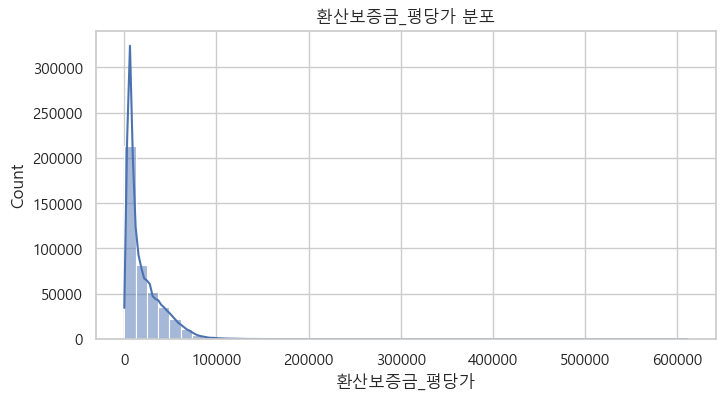

In [6]:
# 타깃 분포
plt.figure(figsize=(8, 4))
sns.histplot(df_train[TARGET].dropna(), bins=50, kde=True)
plt.title("환산보증금_평당가 분포")
plt.show()

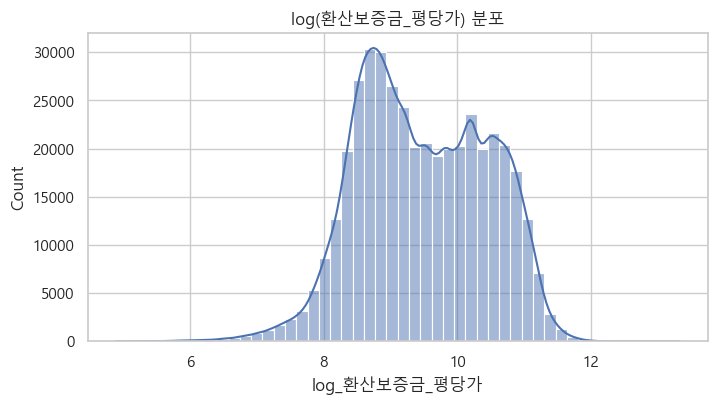

In [7]:
# 로그 스케일 분포 (꼬리 완화용)
df_train[TARGET_LOG] = np.log1p(df_train[TARGET])

plt.figure(figsize=(8, 4))
sns.histplot(df_train[TARGET_LOG].dropna(), bins=50, kde=True)
plt.title("log(환산보증금_평당가) 분포")
plt.show()

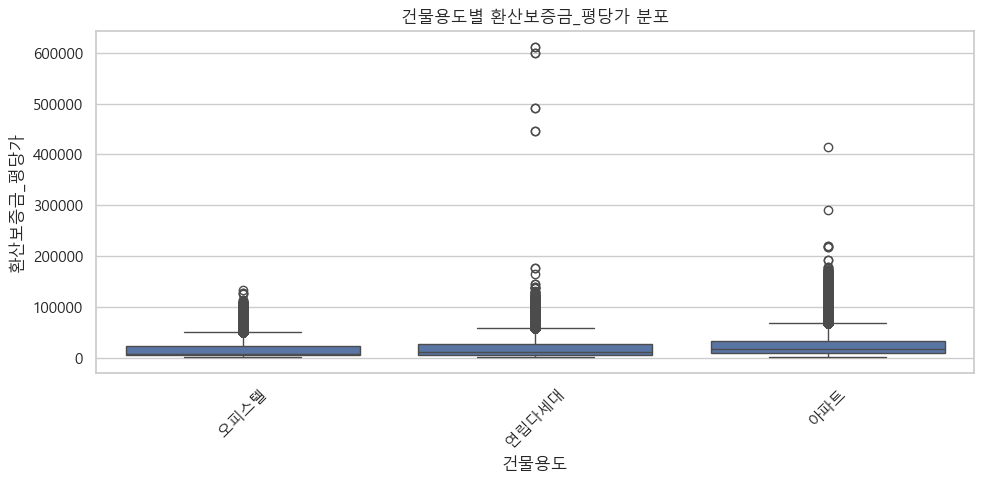

In [8]:
# 건물용도별 평당가 분포
if "건물용도" in df_train.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_train, x="건물용도", y=TARGET)
    plt.xticks(rotation=45)
    plt.title("건물용도별 환산보증금_평당가 분포")
    plt.tight_layout()
    plt.show()

# 아파트 - 분포 가장 넓고, 중위값 높은 편 -> 고급 물건 多, 가격 편차 大
# 연립다세대 - 분포 넓고, 중위값 높은 편 -> 월세 시세 편차 大
# 오피스텔

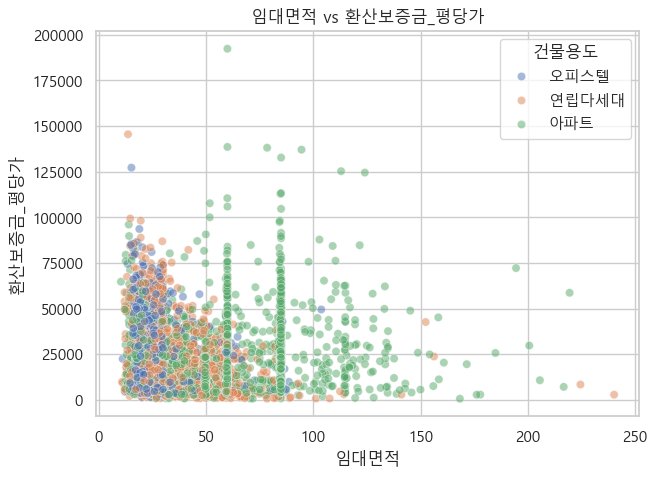

In [9]:
# 임대면적 vs 평당가
plt.figure(figsize=(7, 5))
sample = df_train.sample(min(len(df_train), 4000), random_state=42)
sns.scatterplot(data=sample, x="임대면적", y=TARGET, hue="건물용도", alpha=0.5)
plt.title("임대면적 vs 환산보증금_평당가")
plt.show()

# 가설: 면적이 클수록 평당가가 하락하는가?
# 아파트 - 면적대도 크고 높은 월세 -> 아파트 시세 변동성(std, IQR)을 별도로 둬야 하나..
# 연립/단독/오피스텔 -> 면적이 넓을수록 사라짐 -> 면적대 범주(소/중/대형 등)으로 나눌 수 있을 듯

In [10]:
qbin, bins = pd.qcut(
    df_train["임대면적"],
    q=5,               # 5분위수
    labels=False,
    retbins=True,      # 경계값 반환
    duplicates="drop"
)

df_train["면적_qbin"] = qbin

bin_stats = (
    df_train.groupby("면적_qbin")["임대면적"].agg(["count", "min", "max", "mean"]).reset_index()
)
print(bin_stats)

   면적_qbin  count     min     max       mean
0        0  84856   5.850   20.61  16.948804
1        1  84577  20.620   29.55  25.176447
2        2  84710  29.555   43.73  35.661182
3        3  85662  43.740   59.99  54.174272
4        4  83765  59.991  445.12  89.850780


In [11]:
df_train["면적_qbin"] = qbin

label_map = {
    0: "초소형",     # ~ 22㎡
    1: "소형",       # 22~30㎡
    2: "중소형",     # 30~47㎡
    3: "중형",       # 47~63㎡
    4: "대형이상"    # 63㎡ 이상
}

df_train["면적_qcat"] = df_train["면적_qbin"].map(label_map)
print(df_train["면적_qcat"].value_counts())

면적_qcat
중형      85662
초소형     84856
중소형     84710
소형      84577
대형이상    83765
Name: count, dtype: int64


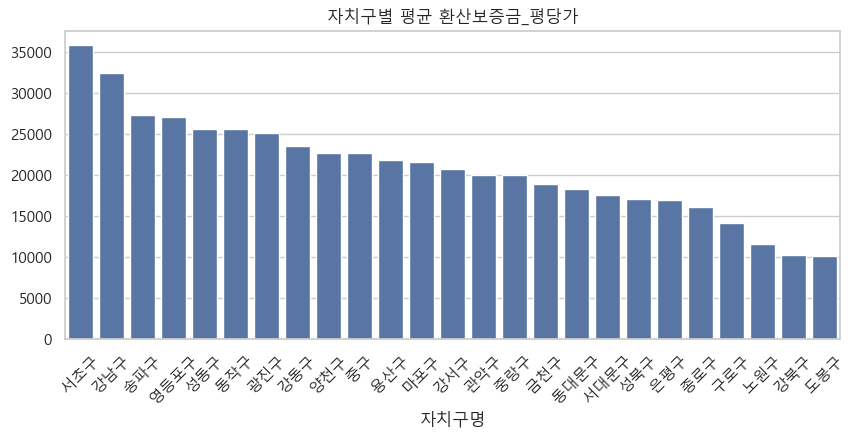

In [12]:
# 자치구별 평균 평당가 (지역 프리미엄)
if {"자치구명", TARGET}.issubset(df.columns):
    gu_mean = df.groupby("자치구명")[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=gu_mean.index.astype(str), y=gu_mean.values)
    plt.xticks(rotation=45)
    plt.title("자치구별 평균 환산보증금_평당가")
    plt.show()

# 강남3구 -> top1

In [13]:
col = "자치구명"

# 각 범주의 개수와 비율 확인
stats = pd.concat(
    [
        df_train[col].value_counts(dropna=False),
        df_train[col].value_counts(normalize=True, dropna=False)
    ],
    axis=1
)
stats.columns = ["count", "ratio"]
print(stats)

      count     ratio
자치구명                 
송파구   42332  0.099941
강서구   37367  0.088219
강남구   29958  0.070727
마포구   24737  0.058401
강동구   24387  0.057575
영등포구  23468  0.055405
서초구   22053  0.052065
관악구   18058  0.042633
동대문구  17716  0.041825
구로구   17334  0.040924
은평구   16133  0.038088
노원구   14662  0.034615
광진구   14221  0.033574
양천구   13388  0.031608
성동구   12499  0.029509
금천구   12443  0.029376
동작구   12343  0.029140
서대문구  12330  0.029110
성북구   10696  0.025252
중랑구   10246  0.024190
용산구    8850  0.020894
중구     7726  0.018240
도봉구    7356  0.017367
강북구    6635  0.015664
종로구    6632  0.015657


In [14]:
east  = ["광진구", "중랑구", "동대문구", "성동구", "강동구", "송파구"]
west  = ["은평구", "서대문구", "마포구", "강서구", "양천구", "영등포구", "구로구", "금천구"]
south = ["강남구", "서초구", "동작구", "관악구"]

def map_direction(gu):
    if gu in east:  
        return "동부"
    if gu in west:  
        return "서부"
    if gu in south: 
        return "남부"
    return "북부"

df_train["구_권역"] = df_train["자치구명"].apply(map_direction)

col = "구_권역"

stats = pd.concat(
    [
        df_train[col].value_counts(dropna=False),
        df_train[col].value_counts(normalize=True, dropna=False)
    ],
    axis=1
)
stats.columns = ["count", "ratio"]
print(stats)

# 구권역에 불균형 존재 ->동북권으로 합칠까 / 

       count     ratio
구_권역                  
서부    157200  0.371131
동부    121401  0.286614
남부     82412  0.194565
북부     62557  0.147690


In [15]:
from scipy import stats as ss

# 권역별 타깃 데이터 묶고
groups = []

for name, group in df_train.groupby("구_권역"):
    values = group[TARGET_LOG].dropna()
    groups.append(values)

# Kruskal-Wallis 검정
h_stat, p_value = ss.kruskal(*groups)

print("구_권역 Kruskal p-value:", p_value)


구_권역 Kruskal p-value: 0.0


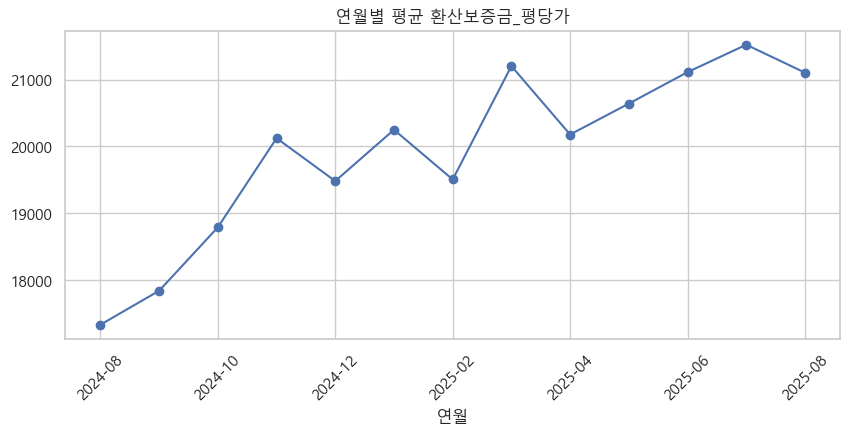

In [16]:
# 시간(연월)에 따른 시세 흐름
if {"연월", TARGET}.issubset(df_train.columns):
    month_mean = df_train.groupby("연월")[TARGET].mean()
    plt.figure(figsize=(10, 4))
    month_mean.plot(marker="o")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.title("연월별 평균 환산보증금_평당가")
    plt.show()

In [17]:
df_train = train.copy()

# 연월을 datetime으로 변환
df_train["연월"] = pd.to_datetime(df_train["연월"], errors='coerce')

# 변환 실패한 행 확인
failed_rows = df_train[df_train["연월"].isnull()]
print(f"변환 실패한 행 수: {len(failed_rows)}")
if len(failed_rows) > 0:
    print("실패한 샘플:")
    print(failed_rows[["연월"]].head())

# 분기 생성
df_train["분기"] = df_train["연월"].dt.quarter
df_train["분기_라벨"] = df_train["분기"].astype(str) + "분기"

print("\n=== 분기 분포 ===")
print(df_train["분기_라벨"].value_counts().sort_index())

변환 실패한 행 수: 0

=== 분기 분포 ===
분기_라벨
1분기    124907
2분기    120832
3분기    112023
4분기     65808
Name: count, dtype: int64


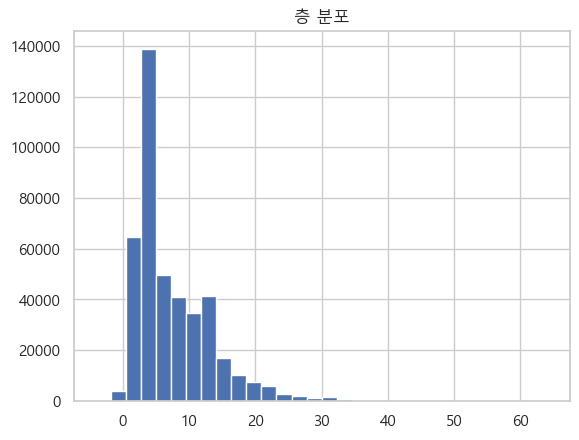

In [18]:
df_train["층"].hist(bins=30); plt.title("층 분포"); plt.show()

In [19]:
df_train['층'].describe()

count    423570.000000
mean          7.526069
std           5.864056
min          -4.000000
25%           3.000000
50%           6.000000
75%          11.000000
max          64.000000
Name: 층, dtype: float64

In [23]:
df_train["층_bin"] = pd.cut(
    df_train["층"],
    bins=[0, 3, 6, 11, 70],
    labels=["저층", "중층", "중고층", "고층"]
)
# df_train["층_bin"].hist(bins=30); plt.title("층 구간 분포"); plt.show()
print(df_train['층_bin'].value_counts())

층_bin
저층     117038
중층     113001
중고층     98739
고층      91011
Name: count, dtype: int64


In [ ]:
df_train["면적X층_카테고리"] = df_train["면적_qcat"].astype(str) + "_" + df_train["층_bin"].astype(str)

# 희소 카테고리 병합
vc = df_train["면적X층_카테고리"].value_counts()
rare = vc[vc < 200].index  # 기준은 상황에 맞게 조정
df_train.loc[df_train["면적X층_카테고리"].isin(rare), "면적X층_카테고리"] = "RARE"

print(df_train["면적X층_카테고리"].value_counts().head(20))

면적X층_카테고리
중소형_저층      28710
대형이상_고층     26762
소형_중층       26507
중형_저층       26472
초소형_중층      25099
초소형_중고층     24623
중소형_중층      23946
소형_저층       22630
소형_중고층      20621
중형_중층       20372
대형이상_저층     20273
중형_고층       19758
대형이상_중고층    19075
초소형_저층      18953
중형_중고층      17814
대형이상_중층     17077
중소형_중고층     16606
초소형_고층      16081
소형_고층       14553
중소형_고층      13857
Name: count, dtype: int64


In [ ]:
from scipy import stats as ss

groups = [g[TARGET_LOG].dropna() for _, g in df.groupby(df_train["면적X층_카테고리"])]
h, p = ss.kruskal(*groups)
print("면적X층_카테고리 Kruskal p-value:", p)


면적X층_카테고리 Kruskal p-value: 0.7986649689467322


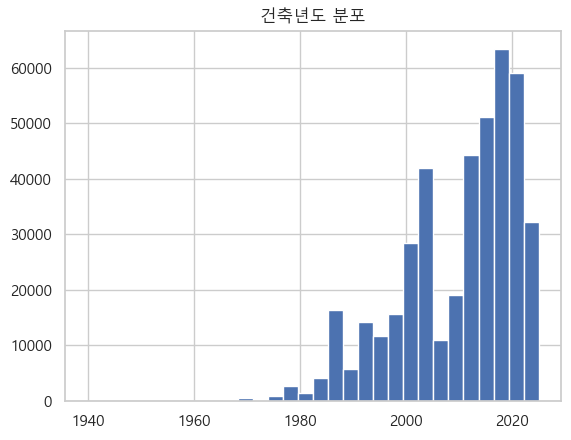

In [ ]:
df_train['건축년도'].hist(bins=30); plt.title("건축년도 분포"); plt.show()

In [ ]:
df_train['건축년도'].describe()

count    423570.000000
mean       2009.968784
std          11.088632
min        1940.000000
25%        2003.000000
50%        2013.000000
75%        2019.000000
max        2025.000000
Name: 건축년도, dtype: float64

In [ ]:
df_train["계약연도"] = pd.to_datetime(df_train["연월"]).dt.year
df_train["건축연차"] = df_train["계약연도"] - df_train["건축년도"]

df_train["연식_구간"] = pd.cut(
    df_train["건축연차"],
    bins=[-1, 5, 10, 20, 30, 100],
    labels=["신축(≤5년)", "준신축(6~10년)", "중간연식(11~20년)", "준노후(21~30년)", "노후(>30년)"]
)
print(df_train["연식_구간"].value_counts())

연식_구간
중간연식(11~20년)    98740
준신축(6~10년)      98196
신축(≤5년)         95246
준노후(21~30년)     82200
노후(>30년)        49107
Name: count, dtype: int64


In [ ]:
# df_train['건축연차'].value_counts()

df_train[["계약연도","건축년도", "건축연차"]].drop_duplicates()

,계약연도,건축년도,건축연차
0,2024,1998.0,26.0
1,2024,1996.0,28.0
2,2024,2023.0,1.0
3,2024,2020.0,4.0
4,2024,1997.0,27.0
...,...,...,...
114122,2025,1968.0,57.0
176215,2025,1963.0,62.0
202778,2025,1962.0,63.0
275425,2025,1961.0,64.0


In [ ]:
df_train["건축시대"] = pd.cut(
    df_train["건축년도"],
    bins=[0, 2000, 2010, 2020, 2025],
    labels=["2000년 이전", "00년대", "10년대", "20년대 이후"]
)

print(df_train["건축시대"].value_counts())

건축시대
10년대        179367
00년대         94332
2000년 이전     79239
20년대 이후      70632
Name: count, dtype: int64


In [ ]:
for col in ["연식_구간", "건축시대"]:
    print(f"\n=== {col} 분포 ===")
    stats = pd.concat(
        [
            df_train[col].value_counts(dropna=False),
            df_train[col].value_counts(normalize=True, dropna=False)
        ],
        axis=1
    )
    stats.columns = ["count", "ratio"]
    print(stats)



=== 연식_구간 분포 ===
              count     ratio
연식_구간                        
중간연식(11~20년)  98740  0.233114
준신축(6~10년)    98196  0.231829
신축(≤5년)       95246  0.224865
준노후(21~30년)   82200  0.194065
노후(>30년)      49107  0.115936
NaN              81  0.000191

=== 건축시대 분포 ===
           count     ratio
건축시대                      
10년대      179367  0.423465
00년대       94332  0.222707
2000년 이전   79239  0.187074
20년대 이후    70632  0.166754


In [ ]:
# 복합 카테고리 생성
df_train["자치구_건물용도"] = df_train["자치구명"] + "_" + df_train["건물용도"]

df_train["자치구_건물용도"]

0          마포구_오피스텔
1         종로구_연립다세대
2         강북구_연립다세대
3         용산구_연립다세대
4         종로구_연립다세대
            ...    
423565    강동구_연립다세대
423566    서초구_연립다세대
423567      성동구_아파트
423568      구로구_아파트
423569    노원구_연립다세대
Name: 자치구_건물용도, Length: 423570, dtype: object

---

In [ ]:
# 자치구별 샘플 수 (인기 지역 지표)
gu_count = df_train.groupby("자치구명").size().to_dict()
df_train["자치구_거래량"] = df_train["자치구명"].map(gu_count)

df_train[["자치구명", "자치구_거래량"]].drop_duplicates()

,자치구명,자치구_거래량
0,마포구,24737
1,종로구,6632
2,강북구,6635
3,용산구,8850
8,성동구,12499
12,성북구,10696
14,송파구,42332
16,관악구,18058
20,동작구,12343
21,중랑구,10246


In [ ]:
qbin, bins = pd.qcut(
    df_train["자치구_거래량"],
    q=3,              
    labels=['상위거래구','중위거래구','하위거래구'],
    retbins=True,     
    duplicates="drop"
)

df_train["자치구_거래량_구간"] = qbin

df_train["자치구_거래량_구간"].value_counts()

자치구_거래량_구간
상위거래구    150027
중위거래구    139149
하위거래구    134394
Name: count, dtype: int64

In [ ]:
print(df_train["자치구_거래량_구간"].value_counts(normalize=True))

자치구_거래량_구간
상위거래구    0.354196
중위거래구    0.328515
하위거래구    0.317289
Name: proportion, dtype: float64


In [ ]:
# TARGET_LOG = "log_환산보증금_평당가"

# 구간별 타깃 평균/중위값
print(
    df_train.groupby("자치구_거래량_구간")[TARGET_LOG]
            .agg(count="count", mean="mean", median="median")
)

# 통계 검정(Kruskal)
from scipy import stats as ss
groups = [g[TARGET_LOG].dropna() for _, g in df_train.groupby("자치구_거래량_구간")]
h, p = ss.kruskal(*groups)
print("자치구_거래량_구간 Kruskal p-value:", p)


             count      mean    median
자치구_거래량_구간                            
상위거래구       150027  9.341270  9.252072
중위거래구       139149  9.520684  9.462780
하위거래구       134394  9.589383  9.554492
자치구_거래량_구간 Kruskal p-value: 0.0


C:\Users\Playdata\AppData\Local\Temp\ipykernel_1484\2181679049.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby("자치구_거래량_구간")[TARGET_LOG]
C:\Users\Playdata\AppData\Local\Temp\ipykernel_1484\2181679049.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[TARGET_LOG].dropna() for _, g in df_train.groupby("자치구_거래량_구간")]


In [ ]:
# 법정동별 샘플 수
dong_count = df_train.groupby("법정동명").size().to_dict()
df_train["법정동_거래량"] = df_train["법정동명"].map(dong_count)

df_train[["법정동명", "법정동_거래량"]].drop_duplicates()

,법정동명,법정동_거래량
0,노고산동,783
1,명륜3가,282
2,수유동,2950
3,용산동2가,150
8,행당동,1836
...,...,...
180783,견지동,8
190465,개화동,6
252562,삼청동,2
273437,신문로1가,2


<Axes: >

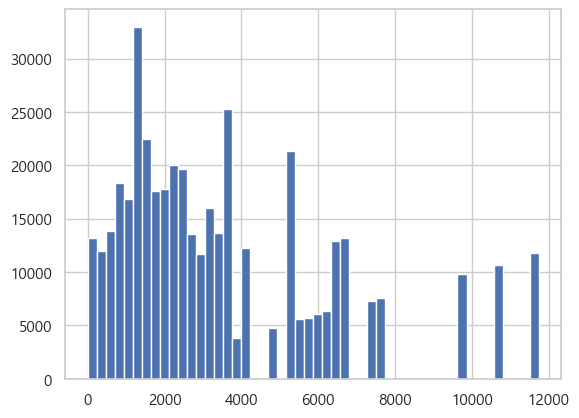

In [ ]:
df_train["법정동_거래량"].describe()
df_train["법정동_거래량"].hist(bins=50)

In [ ]:
df_train["법정동_거래량_log"] = np.log10(df_train["법정동_거래량"])
# df_train["법정동_거래량_log"].describe()

bins = [0, 3.0, 4.0, np.inf]
labels = ["적음", "보통", "많음"]

df_train["법정동_거래량_구간"] = pd.cut(
    df_train["법정동_거래량_log"],
    bins=bins,
    labels=labels
)
df_train["법정동_거래량_구간"].value_counts()

법정동_거래량_구간
보통    338059
적음     63089
많음     22421
Name: count, dtype: int64

In [ ]:
# 자치구별 평균 건물연식 (오래된 동네 vs 신도시)
gu_age = df_train.groupby("자치구명")["건축연차"].mean().to_dict()
df_train["자치구_평균건물연식"] = df_train["자치구명"].map(gu_age)

# df_train["자치구_평균건물연식"].value_counts()
df_train[["자치구명", "자치구_평균건물연식"]].drop_duplicates()

,자치구명,자치구_평균건물연식
0,마포구,14.567571
1,종로구,16.557600
2,강북구,15.135041
3,용산구,16.859322
8,성동구,14.979758
12,성북구,14.515239
14,송파구,15.410942
16,관악구,14.888969
20,동작구,14.815118
21,중랑구,12.116728


In [ ]:
# # 지역별 면적당 거래량 (인기 지표)
df_test_gu_area = df_train.groupby("자치구명")["임대면적"].mean().to_dict()
df_train["자치구_평균면적"] = df_train["자치구명"].map(df_test_gu_area)

df_train["자치구_평균면적"].value_counts()

자치구_평균면적
47.089130    42332
34.647051    37367
55.832478    29958
40.325240    24737
42.409016    24387
37.427072    23468
59.138911    22053
35.500366    18058
38.117888    17716
42.526873    17334
40.546542    16133
48.433004    14662
37.933514    14221
53.827678    13388
53.363111    12499
36.082156    12443
48.492017    12343
42.675062    12330
48.564533    10696
39.968993    10246
60.927915     8850
40.705350     7726
46.054285     7356
39.286057     6635
42.193729     6632
Name: count, dtype: int64

In [ ]:
# 금리_평균이 없다면 먼저 계산
rate_cols = ["무담보콜금리", "KORIBOR", "CD", "기업대출", "전세자금대출", "변동형주택담보대출"]
df_train["금리_평균"] = df_train[rate_cols].mean(axis=1)

df_train["금리_MA_6"] = (
    df_train["금리_평균"]
      .rolling(window=6, min_periods=1)
      .mean()
)

df_train["금리_편차"] = (df_train["금리_평균"] - df_train["금리_MA_6"])

df_train["금리_국면"] = pd.cut(
    df_train["금리_편차"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["인하국면", "동결국면", "인상국면"]
)

df_train["금리_국면"].value_counts()


금리_국면
동결국면    418440
인하국면      3579
인상국면      1551
Name: count, dtype: int64

In [ ]:
mean_rate = df_train["금리_평균"].mean()
std_rate = df_train["금리_평균"].std()

df_train["금리_z"] = ((df_train["금리_평균"] - mean_rate) / std_rate)

df_train["금리_z_구간"] = pd.cut(
    df_train["금리_z"],
    bins=[-np.inf, -1, 1, np.inf],
    labels=["낮음", "보통", "높음"]
)

df_train["금리_z_구간"].value_counts()

금리_z_구간
보통    204687
낮음    121738
높음     97145
Name: count, dtype: int64

In [ ]:
# 자치구별 평균 계산
gu_mean_area = df_train.groupby("자치구명")["전용평수"].mean().to_dict()
gu_mean_year = df_train.groupby("자치구명")["건축년도"].mean().to_dict()
gu_mean_floor = df_train.groupby("자치구명")["층"].mean().to_dict()

# 각 행에 자치구 평균 매핑
df_train["자치구_평균_전용면적"] = df_train["자치구명"].map(gu_mean_area)
df_train["자치구_평균_건축연도"] = df_train["자치구명"].map(gu_mean_year)
df_train["자치구_평균_층수"] = df_train["자치구명"].map(gu_mean_floor)

# 평균 대비 비율 계산 (해당 매물 / 자치구 평균)
df_train["평균대비_전용면적"] = df_train["전용평수"] / df_train["자치구_평균_전용면적"]
df_train["평균대비_건축연도"] = df_train["건축년도"] / df_train["자치구_평균_건축연도"]
df_train["평균대비_층수"] = df_train["층"] / df_train["자치구_평균_층수"]

In [ ]:
df_train["자치구_평균_전용면적"].describe()

count    423570.000000
mean         13.418012
std           2.276547
min          10.499106
25%          11.550875
50%          12.851217
75%          14.694551
max          18.463005
Name: 자치구_평균_전용면적, dtype: float64

In [ ]:
df_train["평균대비_전용면적"].describe()

count    423570.000000
mean          1.000000
std           0.606907
min           0.154217
25%           0.535971
50%           0.822580
75%           1.338487
max          12.538462
Name: 평균대비_전용면적, dtype: float64

In [ ]:
for col in ["평균대비_전용면적", "평균대비_건축연도", "평균대비_층수"]:
    mu = df_train[col].mean()
    sigma = df_train[col].std()
    df_train[col + "_z"] = (df_train[col] - mu) / sigma

def z_bin(z):
    if z <= -1:
        return "낮음"
    elif z <= 1:
        return "보통"
    else:
        return "높음"

df_train["전용면적_자치구수준_z"] = df_train["평균대비_전용면적_z"].apply(z_bin)
df_train["건축연도_자치구수준_z"] = df_train["평균대비_건축연도_z"].apply(z_bin)
df_train["층수_자치구수준_z"]     = df_train["평균대비_층수_z"].apply(z_bin)

df_train[["전용면적_자치구수준_z","건축연도_자치구수준_z", "층수_자치구수준_z"]].drop_duplicates().count()

In [ ]:
df_train = train.copy()

df_train["연월"] = pd.to_datetime(df_train["연월"], format="%Y-%m")

df_train["계약월"] = df_train["연월"].dt.month

def map_season(m):
    if m in [3, 4, 5]:
        return "봄"
    if m in [6, 7, 8]:
        return "여름"
    if m in [9, 10, 11]:
        return "가을"
    # 12, 1, 2
    return "겨울"

df_train["계약_계절"] = df_train["계약월"].apply(map_season)

df_train["계약_계절"].value_counts()

계약_계절
여름    138567
봄     119208
겨울    114051
가을     51744
Name: count, dtype: int64

In [ ]:
# 2. 계약 반기 (상반기/하반기)
df_train["계약_반기"] = np.where(df_train["계약월"] <= 6, "상반기", "하반기")

df_train["계약_반기"].value_counts()

계약_반기
상반기    245739
하반기    177831
Name: count, dtype: int64

In [27]:
# 6. 보증금 구간 (하위/중위/상위 3분위 구간)
dep_q = df_train["보증금(만원)"].quantile([0.33, 0.66])
df_train["보증금_구간"] = pd.cut(
    df_train["보증금(만원)"],
    bins=[-np.inf, dep_q.iloc[0], dep_q.iloc[1], np.inf],
    labels=["저보증금", "중간보증금", "고보증금"],
)

df_train["보증금_구간"].value_counts()

보증금_구간
고보증금     144014
저보증금     139780
중간보증금    139776
Name: count, dtype: int64

In [31]:
rent_q = df_train["임대료(만원)"].quantile([0.33, 0.66])
df_train["임대료_구간"] = pd.cut(
        df_train["임대료(만원)"],
        bins=[-np.inf, rent_q.iloc[0], rent_q.iloc[1], np.inf],
        labels=["저임대료", "중간임대료", "고임대료"],
)

df_train["임대료_구간"].value_counts()

임대료_구간
중간임대료    143460
저임대료     140756
고임대료     139354
Name: count, dtype: int64

In [30]:
cpi_q = df_train["소비자물가"].quantile([0.33, 0.66])
df_train["소비자물가_레벨"] = pd.cut(
        df_train["소비자물가"],
        bins=[-np.inf, cpi_q.iloc[0], cpi_q.iloc[1], np.inf],
        labels=["저물가", "보통물가", "고물가"],
)

df_train["소비자물가_레벨"].value_counts()

소비자물가_레벨
보통물가    182870
저물가     161138
고물가      79562
Name: count, dtype: int64

In [32]:
rate_q = df_train["기준금리"].quantile([0.33, 0.66])
df_train["기준금리_레벨"] = pd.cut(
        df_train["기준금리"],
        bins=[-np.inf, rate_q.iloc[0], rate_q.iloc[1], np.inf],
        labels=["저금리", "중간금리", "고금리"],
)

df_train["기준금리_레벨"].value_counts()

기준금리_레벨
저금리     240946
중간금리    114051
고금리      68573
Name: count, dtype: int64

In [33]:
# 16. KORIBOR - 기준금리 스프레드 구간
df_train["KORIBOR_스프레드"] = df_train["KORIBOR"] - df_train["기준금리"]
spread_q = df_train["KORIBOR_스프레드"].quantile([0.33, 0.66])
df_train["KORIBOR_스프레드_구간"] = pd.cut(
        df_train["KORIBOR_스프레드"],
        bins=[-np.inf, spread_q.iloc[0], spread_q.iloc[1], np.inf],
        labels=["낮은 스프레드", "보통 스프레드", "높은 스프레드"],
)

df_train["KORIBOR_스프레드_구간"].value_counts()

KORIBOR_스프레드_구간
낮은 스프레드    176595
높은 스프레드    126279
보통 스프레드    120696
Name: count, dtype: int64

In [34]:
# 8. 보증금/임대료 비율 구간
ratio = df_train["보증금(만원)"] / df_train["임대료(만원)"].replace({0: np.nan})
ratio_q = ratio.quantile([0.33, 0.66])
df_train["보증금임대료비율_구간"] = pd.cut(
        ratio,
        bins=[-np.inf, ratio_q.iloc[0], ratio_q.iloc[1], np.inf],
        labels=["저비율", "중간비율", "고비율"],
)

df_train["보증금임대료비율_구간"].value_counts()

보증금임대료비율_구간
고비율     17755
저비율     17305
중간비율    17170
Name: count, dtype: int64

In [53]:
# 0. 연월 정렬
df_train = df_train.sort_values("연월").reset_index(drop=True)
df_train["연월_dt"] = pd.to_datetime(df_train["연월"])

# 1. 연월별(월 단위) 금리 테이블 만들기 (중복 제거)
macro = (
    df_train[["연월", "연월_dt", "기준금리"]]
    .drop_duplicates()
    .sort_values("연월_dt")
    .reset_index(drop=True)
)

# 2. 전월 기준금리 값 계산 (연월 순으로 한 칸 shift)
macro["기준금리_전월값"] = macro["기준금리"].shift(1)

# 3. 원본 df에 연월 기준으로 매핑
df_train = df_train.merge(
    macro[["연월", "기준금리_전월값"]],
    on="연월",
    how="left"
)

# 4. 전월 대비 변화율 및 범주
df_train["기준금리_전월대비변화"] = (
    (df_train["기준금리"] - df_train["기준금리_전월값"]) / df_train["기준금리_전월값"]
)

def sign_cat_label(x):
    if pd.isna(x):
        return "변화없음"
    if x > 0:
        return "상승"
    if x < 0:
        return "하락"
    return "변화없음"

df_train["기준금리_전월대비_범주"] = (
    df_train["기준금리_전월대비변화"].apply(sign_cat_label).astype("category")
)

df_train["기준금리_전월대비_범주"].value_counts()


기준금리_전월대비_범주
변화없음    294749
하락      128821
Name: count, dtype: int64

In [43]:
# 1) 자치구-연월 그룹 평균
gu_month_mean = (
    df_train.groupby(["자치구명", "연월"])["임대료(만원)"]
      .transform("mean")
)
df_train["자치구_월별_평균임대료"] = gu_month_mean

# 2) 계약 임대료 / 평균 비율
ratio = df_train["임대료(만원)"] / df_train["자치구_월별_평균임대료"]
df_train["자치구_월별_평균대비비율"] = ratio

# 3) 범주화 (예: ±10% 기준)
def level_cat(r):
    if pd.isna(r):
        return "정보없음"
    if r < 0.9:
        return "평균보다저렴"
    if r > 1.1:
        return "평균보다비쌈"
    return "평균수준"

df_train["자치구_월별_임대료수준_구간"] = df_train["자치구_월별_평균대비비율"].apply(level_cat)

df_train["자치구_월별_임대료수준_구간"].value_counts()


자치구_월별_임대료수준_구간
평균보다저렴    234148
평균보다비쌈    140459
평균수준       48963
Name: count, dtype: int64

In [56]:
# 연월은 이미 문자열 "YYYY-MM" 형태라고 가정
df_train = df_train.sort_values("연월").reset_index(drop=True)
df_train["연월_dt"] = pd.to_datetime(df_train["연월"])

# 1) 자치구 건물용도별 월별 임대료 평균
df_train["자치구_용도_월별_임대료_평균"] = (
    df_train
    .groupby(["자치구명", "건물용도", "연월"])["임대료(만원)"]
    .transform("mean")
)

df_train["자치구_용도_월별_임대료_평균"].value_counts()
df_train[["자치구_용도_월별_임대료_평균", "자치구명", "건물용도","연월"]].drop_duplicates()


,자치구_용도_월별_임대료_평균,자치구명,건물용도,연월
0,40.488095,노원구,연립다세대,2024-08-01
1,56.838863,성북구,연립다세대,2024-08-01
2,56.381579,중구,연립다세대,2024-08-01
3,50.862821,강서구,오피스텔,2024-08-01
4,86.479339,중구,오피스텔,2024-08-01
...,...,...,...,...
384378,67.926554,도봉구,오피스텔,2025-08-01
384433,50.211845,양천구,연립다세대,2025-08-01
384461,74.374194,도봉구,아파트,2025-08-01
384584,93.774390,서초구,오피스텔,2025-08-01


In [57]:
# 2) 법정동 건물용도별 월별 임대료 평균
df_train["법정동_용도_월별_임대료_평균"] = (
    df_train
    .groupby(["법정동명", "건물용도", "연월"])["임대료(만원)"]
    .transform("mean")
)

df_train[["법정동_용도_월별_임대료_평균", "자치구명", "건물용도","연월"]].drop_duplicates()

,법정동_용도_월별_임대료_평균,자치구명,건물용도,연월
0,48.852941,노원구,연립다세대,2024-08-01
1,93.800000,성북구,연립다세대,2024-08-01
2,64.230769,중구,연립다세대,2024-08-01
3,46.977273,강서구,오피스텔,2024-08-01
4,78.285714,중구,오피스텔,2024-08-01
...,...,...,...,...
420091,100.000000,종로구,연립다세대,2025-08-01
421046,60.000000,마포구,오피스텔,2025-08-01
421071,75.000000,동작구,오피스텔,2025-08-01
421607,100.000000,성북구,연립다세대,2025-08-01


In [58]:
# 3) 법정동_월별_임대료_중앙값
df_train["법정동_월별_임대료_중앙값"] = (
    df_train
    .groupby(["법정동명", "연월"])["임대료(만원)"]
    .transform("median")
)

df_train[["법정동_월별_임대료_중앙값", "법정동명", "연월"]].drop_duplicates()

,법정동_월별_임대료_중앙값,법정동명,연월
0,55.0,공릉동,2024-08-01
1,105.0,길음동,2024-08-01
2,83.0,신당동,2024-08-01
3,55.0,가양동,2024-08-01
4,41.5,광희동1가,2024-08-01
...,...,...,...
419143,80.0,문래동2가,2025-08-01
419337,380.0,충무로4가,2025-08-01
419648,69.0,관수동,2025-08-01
420091,100.0,통인동,2025-08-01


In [59]:
# 4) 면적대비_임대료_중앙값
#   - 먼저 개별 계약의 면적대비 임대료를 만들고
#   - 법정동+연월 기준 중앙값을 피처로 사용 (원하는 그룹 기준에 맞게 조정 가능)
df_train["면적대비_임대료"] = df_train["임대료(만원)"] / df_train["임대면적"]

df_train["법정동_월별_면적대비_임대료_중앙값"] = (
    df_train
    .groupby(["법정동명", "연월"])["면적대비_임대료"]
    .transform("median")
)


df_train[["법정동_월별_면적대비_임대료_중앙값", "법정동명", "연월"]].drop_duplicates()

,법정동_월별_면적대비_임대료_중앙값,법정동명,연월
0,1.683502,공릉동,2024-08-01
1,1.833639,길음동,2024-08-01
2,2.075435,신당동,2024-08-01
3,1.804186,가양동,2024-08-01
4,2.121999,광희동1가,2024-08-01
...,...,...,...
419143,1.367054,문래동2가,2025-08-01
419337,3.308952,충무로4가,2025-08-01
419648,3.799559,관수동,2025-08-01
420091,1.155135,통인동,2025-08-01


In [64]:
df_train['보증금_지역대비'] = (
    df_train['보증금(만원)'] /
    df_train.groupby('자치구명')['보증금(만원)'].transform('mean')
)

df_train['보증금_지역대비']

0         0.030585
1         0.390668
2         0.100133
3         1.174729
4         1.001328
            ...   
423565    0.300399
423566    0.772961
423567    0.059305
423568    0.977375
423569    0.107877
Name: 보증금_지역대비, Length: 423570, dtype: float64

In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_train = train.copy()
df_test = test.copy()

# 1) 연월 관련 기본 파생: 계약연도, 계약월, 건축연차
for df in [df_train, df_test]:
    df["계약연도"] = pd.to_datetime(df["연월"]).dt.year
    df["계약월"] = pd.to_datetime(df["연월"]).dt.month
    df["건축연차"] = df["계약연도"] - df["건축년도"]

# 2) 자치구별 거래량 (Train 기준 → Train/Test에 매핑)
gu_count = df_train.groupby("자치구명").size().to_dict()
for df in [df_train, df_test]:
    df["자치구_거래량"] = df["자치구명"].map(gu_count)

# 3) 계절 컬럼 (계약_계절)
def map_season(m):
    if m in [3, 4, 5]:
        return "봄"
    if m in [6, 7, 8]:
        return "여름"
    if m in [9, 10, 11]:
        return "가을"
    # 12, 1, 2
    return "겨울"

for df in [df_train, df_test]:
    df["계약_계절"] = df["계약월"].apply(map_season)

# 4) 금리_평균 (preprocessor.py와 동일한 rate_cols 사용)
rate_cols = ["무담보콜금리", "KORIBOR", "CD", "기업대출", "전세자금대출", "변동형주택담보대출"]

for df in [df_train, df_test]:
    df["금리_평균"] = df[rate_cols].mean(axis=1)

# 5) 자치구명_LE 생성 (Label Encoding)
le_gu = LabelEncoder()
all_gu = pd.concat([df_train["자치구명"], df_test["자치구명"]]).astype(str)
le_gu.fit(all_gu)

df_train["자치구명_LE"] = le_gu.transform(df_train["자치구명"].astype(str))
df_test["자치구명_LE"] = le_gu.transform(df_test["자치구명"].astype(str))

# 6) 상호작용 피처 생성
for df in [df_train, df_test]:
    # 1. 중요 Feature 간 곱셈 교호작용
    df["면적_x_건축연차"] = df["임대면적"] * df["건축연차"]
    df["자치구거래량_x_면적"] = df["자치구_거래량"] * df["임대면적"]

    # 2. 금리와 지역의 교호작용
    df["자치구_x_금리평균"] = df["자치구명_LE"] * df["금리_평균"]

    # 3. 계절 × 자치구 (계절별 지역 선호도)
    df["계절_x_자치구"] = df["계약_계절"].astype(str) + "_" + df["자치구명"].astype(str)

# 7) 결과 샘플 확인 (train 기준)
df_train[[
    "면적_x_건축연차",
    "자치구거래량_x_면적",
    "자치구_x_금리평균",
    "계절_x_자치구"
]].head()


,면적_x_건축연차,자치구거래량_x_면적,자치구_x_금리평균,계절_x_자치구
0,809.12,769815.44,45.990000,겨울_마포구
1,586.88,139006.72,85.943000,가을_종로구
2,20.00,132700.00,7.813000,가을_강북구
3,87.36,193284.00,78.350000,가을_용산구
4,1284.66,315550.56,84.373667,여름_종로구


In [17]:
import pandas as pd
import numpy as np

df_train = train.copy()

# 1) 동 전체 매물 수, 동×용도 매물 수 계산
dong_total = df_train.groupby("법정동명").size().rename("동_전체매물수")
dong_usage = df_train.groupby(["법정동명", "건물용도"]).size().rename("동용도_매물수")

rarity_df = (
    dong_usage
    .reset_index()
    .merge(dong_total.reset_index(), on="법정동명", how="left")
)
rarity_df["동용도_비율"] = rarity_df["동용도_매물수"] / rarity_df["동_전체매물수"]

# 2) 분포 요약 통계 확인
print("[동용도_비율 분포 요약]")
print(
    rarity_df["동용도_비율"].describe(
        percentiles=[0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
    )
)

# 3) 대략적인 히스토그램/구간별 카운트 확인 (후보 경계 감 잡기)
bins = [0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
rarity_df["tmp_bin"] = pd.cut(rarity_df["동용도_비율"], bins=bins, include_lowest=True)
print("\n[임시 구간별 동×용도 조합 수]")
print(rarity_df["tmp_bin"].value_counts().sort_index())


[동용도_비율 분포 요약]
count    921.000000
mean       0.418024
std        0.311126
min        0.000846
1%         0.005764
5%         0.023524
10%        0.048689
20%        0.107143
30%        0.174677
50%        0.375000
70%        0.584507
90%        0.928363
95%        1.000000
99%        1.000000
max        1.000000
Name: 동용도_비율, dtype: float64

[임시 구간별 동×용도 조합 수]
tmp_bin
(-0.001, 0.02]     38
(0.02, 0.05]       58
(0.05, 0.1]        82
(0.1, 0.2]        131
(0.2, 0.3]         84
(0.3, 0.5]        184
(0.5, 0.7]        151
(0.7, 1.0]        193
Name: count, dtype: int64


In [ ]:
def make_rarity_bins(rarity_df: pd.DataFrame,
                     thresholds=(0.03, 0.10, 0.30, 0.60)):
    """
    thresholds: (t1, t2, t3, t4)
      0 ~ t1       -> 매우희소
      t1 ~ t2      -> 희소
      t2 ~ t3      -> 보통
      t3 ~ t4      -> 다수
      t4 ~ 1       -> 과밀
    """
    t1, t2, t3, t4 = thresholds

    def rarity_label(p):
        if p <= t1:
            return "매우희소"
        if p <= t2:
            return "희소"
        if p <= t3:
            return "보통"
        if p <= t4:
            return "다수"
        return "과밀"

    rarity_df = rarity_df.copy()
    rarity_df["동용도_희소도_구간"] = rarity_df["동용도_비율"].apply(rarity_label)
    return rarity_df

# 1) 일단 한 번 써보기 (초기값: 3%, 10%, 30%, 60%)
rarity_df2 = make_rarity_bins(rarity_df, thresholds=(0.03, 0.10, 0.30, 0.60))

print("\n[동용도_희소도_구간별 동×용도 조합 수]")
print(rarity_df2["동용도_희소도_구간"].value_counts())

print("\n[각 구간의 비율 범위 예시]")
for label in ["매우희소", "희소", "보통", "다수", "과밀"]:
    sub = rarity_df2[rarity_df2["동용도_희소도_구간"] == label]
    if len(sub) == 0:
        continue
    print(
        f"{label}: n={len(sub)}, "
        f"min={sub['동용도_비율'].min():.4f}, "
        f"median={sub['동용도_비율'].median():.4f}, "
        f"max={sub['동용도_비율'].max():.4f}"
    )



[동용도_희소도_구간별 동×용도 조합 수]
동용도_희소도_구간
다수      335
보통      215
과밀      193
매우희소     96
희소       82
Name: count, dtype: int64

[각 구간의 비율 범위 예시]
매우희소: n=96, min=0.0008, median=0.0235, max=0.0494
희소: n=82, min=0.0513, median=0.0738, max=0.0995
보통: n=215, min=0.1002, median=0.1818, max=0.3000
다수: n=335, min=0.3004, median=0.4692, max=0.7000
과밀: n=193, min=0.7022, median=0.9245, max=1.0000
